In [1]:
import os
import json
import pandas as pd
import numpy as np
from pprint import pprint

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    print(f"Files: {len(filenames)}")
    print("-" * 80)

/kaggle/input
Files: 0
--------------------------------------------------------------------------------
/kaggle/input/datasets
Files: 0
--------------------------------------------------------------------------------
/kaggle/input/datasets/mitanshuchakrawarty
Files: 0
--------------------------------------------------------------------------------
/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset
Files: 0
--------------------------------------------------------------------------------
/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset/IDD_RESIZED
Files: 0
--------------------------------------------------------------------------------
/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset/IDD_RESIZED/mask_archive
Files: 6993
--------------------------------------------------------------------------------
/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset/IDD_RESIZED/image_archive
Files: 6993
------------------------------------------------------------------

In [3]:
import os

label_dir = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels"

print(os.listdir(label_dir))

['bdd100k_labels_images_val.json', 'bdd100k_labels_images_train.json']


In [4]:
import json

bdd_json = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json"

with open(bdd_json, "r") as f:
    data = json.load(f)

print("Number of samples:", len(data))

print("\nFirst sample:\n")
from pprint import pprint
pprint(data[0])

Number of samples: 69863

First sample:

{'attributes': {'scene': 'city street',
                'timeofday': 'daytime',
                'weather': 'clear'},
 'labels': [{'attributes': {'occluded': False,
                            'trafficLightColor': 'green',
                            'truncated': False},
             'box2d': {'x1': 1125.902264,
                       'x2': 1156.978645,
                       'y1': 133.184488,
                       'y2': 210.875445},
             'category': 'traffic light',
             'id': 0,
             'manualAttributes': True,
             'manualShape': True},
            {'attributes': {'occluded': False,
                            'trafficLightColor': 'green',
                            'truncated': False},
             'box2d': {'x1': 1156.978645,
                       'x2': 1191.50796,
                       'y1': 136.637417,
                       'y2': 210.875443},
             'category': 'traffic light',
             'id': 1,

In [5]:
weather_set = set()
scene_set = set()
timeofday_set = set()

for sample in data:

    attrs = sample["attributes"]

    weather_set.add(attrs["weather"])
    scene_set.add(attrs["scene"])
    timeofday_set.add(attrs["timeofday"])

print("Weather:")
print(weather_set)

print("\nScene:")
print(scene_set)

print("\nTime of Day:")
print(timeofday_set)

Weather:
{'undefined', 'partly cloudy', 'overcast', 'foggy', 'clear', 'snowy', 'rainy'}

Scene:
{'tunnel', 'undefined', 'residential', 'gas stations', 'parking lot', 'highway', 'city street'}

Time of Day:
{'undefined', 'dawn/dusk', 'daytime', 'night'}


In [6]:
categories = set()

for sample in data:

    for obj in sample["labels"]:

        categories.add(obj["category"])

print(sorted(categories))

['bike', 'bus', 'car', 'drivable area', 'lane', 'motor', 'person', 'rider', 'traffic light', 'traffic sign', 'train', 'truck']


In [7]:
import os

idd_mask_dir = "/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset/IDD_RESIZED/mask_archive"

mask_files = os.listdir(idd_mask_dir)

print("Number of masks:", len(mask_files))
print("First 10 masks:")
print(mask_files[:10])

Number of masks: 6993
First 10 masks:
['Mask_3419.png', 'Mask_3956.png', 'Mask_953.png', 'Mask_377.png', 'Mask_4495.png', 'Mask_6793.png', 'Mask_980.png', 'Mask_3656.png', 'Mask_2524.png', 'Mask_6782.png']


Shape: (512, 512)
Unique values:
[0 1]


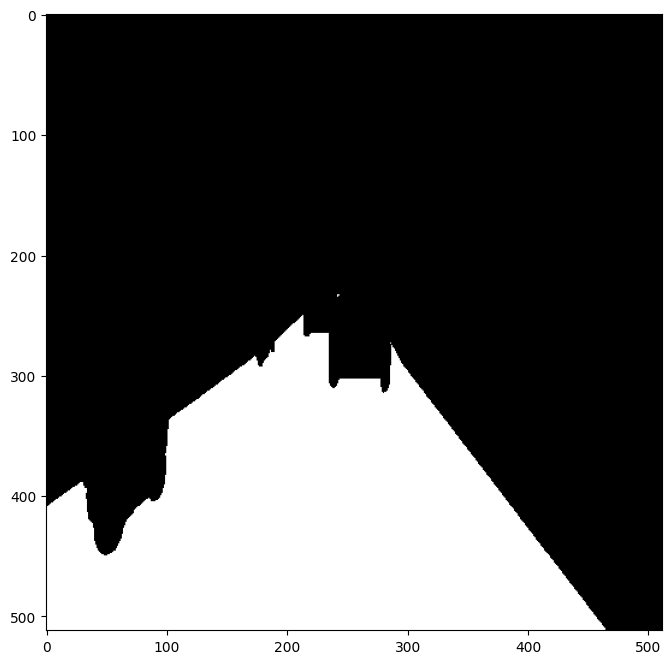

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

mask_path = os.path.join(
    idd_mask_dir,
    mask_files[0]
)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

print("Shape:", mask.shape)

print("Unique values:")
print(np.unique(mask))

plt.figure(figsize=(8,8))
plt.imshow(mask, cmap="gray")
plt.show()

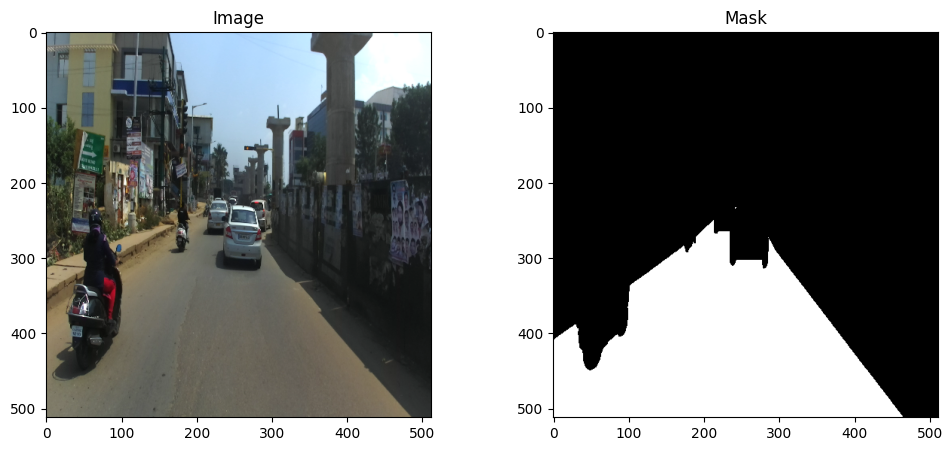

In [9]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = os.path.join(
    "/kaggle/input/datasets/mitanshuchakrawarty/new-idd-dataset/IDD_RESIZED/image_archive",
    mask_files[0].replace("Mask_", "Image_")
)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")

plt.show()

In [10]:
import cv2
import numpy as np

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

white_pixels = np.sum(mask == 1)
total_pixels = mask.size

drivable_area_ratio = white_pixels / total_pixels

print("Drivable Area Ratio:", drivable_area_ratio)

Drivable Area Ratio: 0.27085113525390625


In [11]:
bottom_row = mask[-20:, :]

road_width_bottom = np.sum(bottom_row == 1) / 20

print("Road Width Bottom:", road_width_bottom)

Road Width Bottom: 458.05


In [13]:
def extract_idd_dynamic_state(mask_path):

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    white_pixels = np.sum(mask == 1)

    total_pixels = mask.size

    drivable_area_ratio = white_pixels / total_pixels

    bottom_row = mask[-20:, :]

    road_width_bottom = np.sum(
        bottom_row == 1
    ) / 20

    mid_row = mask[
        mask.shape[0] // 2
    ]

    road_width_middle = np.sum(
        mid_row == 1
    )

    road_complexity_score = (
        1 - drivable_area_ratio
    )

    return {

        "drivable_area_ratio":
            drivable_area_ratio,

        "road_width_bottom":
            road_width_bottom,

        "road_width_middle":
            road_width_middle,

        "road_complexity_score":
            road_complexity_score
    }

In [15]:
import os

waymo_dir = "/kaggle/input/datasets/mohammedosama/waymo-open-training-dataset-1"

files = sorted(os.listdir(waymo_dir))

print("Total files:", len(files))

for f in files[:50]:
    print(f)

Total files: 91
train-00000-of-01212.tfrecords
train-00001-of-01212.tfrecords
train-00002-of-01212.tfrecords
train-00003-of-01212.tfrecords
train-00004-of-01212.tfrecords
train-00005-of-01212.tfrecords
train-00006-of-01212.tfrecords
train-00007-of-01212.tfrecords
train-00008-of-01212.tfrecords
train-00009-of-01212.tfrecords
train-00010-of-01212.tfrecords
train-00011-of-01212.tfrecords
train-00012-of-01212.tfrecords
train-00013-of-01212.tfrecords
train-00014-of-01212.tfrecords
train-00015-of-01212.tfrecords
train-00016-of-01212.tfrecords
train-00017-of-01212.tfrecords
train-00018-of-01212.tfrecords
train-00019-of-01212.tfrecords
train-00020-of-01212.tfrecords
train-00021-of-01212.tfrecords
train-00022-of-01212.tfrecords
train-00023-of-01212.tfrecords
train-00024-of-01212.tfrecords
train-00025-of-01212.tfrecords
train-00026-of-01212.tfrecords
train-00027-of-01212.tfrecords
train-00028-of-01212.tfrecords
train-00029-of-01212.tfrecords
train-00030-of-01212.tfrecords
train-00031-of-01212.tf

In [16]:
for f in files[:10]:
    path = os.path.join(waymo_dir, f)

    print(f)
    print("Size (MB):", round(os.path.getsize(path)/(1024*1024),2))
    print("-"*50)

train-00000-of-01212.tfrecords
Size (MB): 1097.19
--------------------------------------------------
train-00001-of-01212.tfrecords
Size (MB): 1269.93
--------------------------------------------------
train-00002-of-01212.tfrecords
Size (MB): 1114.88
--------------------------------------------------
train-00003-of-01212.tfrecords
Size (MB): 978.27
--------------------------------------------------
train-00004-of-01212.tfrecords
Size (MB): 984.84
--------------------------------------------------
train-00005-of-01212.tfrecords
Size (MB): 1160.93
--------------------------------------------------
train-00006-of-01212.tfrecords
Size (MB): 1069.88
--------------------------------------------------
train-00007-of-01212.tfrecords
Size (MB): 942.11
--------------------------------------------------
train-00008-of-01212.tfrecords
Size (MB): 944.38
--------------------------------------------------
train-00009-of-01212.tfrecords
Size (MB): 1064.95
---------------------------------------------

In [17]:
import tensorflow as tf
import os

waymo_dir = "/kaggle/input/datasets/mohammedosama/waymo-open-training-dataset-1"

sample_file = os.path.join(
    waymo_dir,
    "train-00000-of-01212.tfrecords"
)

dataset = tf.data.TFRecordDataset(
    sample_file,
    compression_type=""
)

for record in dataset.take(1):
    print(type(record))
    print(len(record.numpy()))

2026-06-05 07:29:24.526839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780644564.967295      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780644565.089789      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780644566.149792      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780644566.149839      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780644566.149842      58 computation_placer.cc:177] computation placer alr

<class 'tensorflow.python.framework.ops.EagerTensor'>
8308689


In [18]:
for record in dataset.take(1):

    raw_bytes = record.numpy()

    print(type(raw_bytes))
    print(len(raw_bytes))

    print(raw_bytes[:200])

<class 'bytes'>
8308689
b'\n\xcc\x8f\xfb\x03\nK\n\x1fcameras/front_left/intrinsics/K\x12(\x12&\n$\x93\xdf\x01E\x00\x00\x00\x00\xef\x9bxD\x00\x00\x00\x00\x93\xdf\x01Ez\xab\x1dD\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80?\nD\n(cameras/front_left/intrinsics/distortion\x12\x18\x12\x16\n\x14\xab\x840=\xe8+\xb1\xbeO Q;\xf2\xf0\xae:\x00\x00\x00\x00\n\xde\xf0\x02\n"lidars/rear/camera_projections/ids\x12\xb6\xf0\x02\x1a\xb2\xf0\x02'


In [19]:
try:
    from waymo_open_dataset import dataset_pb2
    print("Waymo API available")
except Exception as e:
    print(e)

No module named 'waymo_open_dataset'


In [20]:
import tensorflow as tf
import os
import re

waymo_dir = "/kaggle/input/datasets/mohammedosama/waymo-open-training-dataset-1"

sample_file = os.path.join(
    waymo_dir,
    "train-00000-of-01212.tfrecords"
)

dataset = tf.data.TFRecordDataset(sample_file)

for record in dataset.take(1):

    text = str(record.numpy())

    matches = re.findall(
        r'[a-zA-Z_]+/[a-zA-Z_]+/[a-zA-Z_]+',
        text
    )

    print(sorted(set(matches))[:100])

['acameras/front/extrinsics', 'acameras/front/intrinsics', 'acameras/front/shutter_type', 'cameras/front/id', 'cameras/front/image', 'cameras/front/intrinsics', 'cameras/front/name', 'cameras/front_left/id', 'cameras/front_left/image', 'cameras/front_left/intrinsics', 'cameras/front_left/name', 'cameras/front_right/extrinsics', 'cameras/front_right/id', 'cameras/front_right/image', 'cameras/front_right/intrinsics', 'cameras/front_right/name', 'cameras/front_right/shutter_type', 'cameras/side_left/id', 'cameras/side_left/image', 'cameras/side_left/intrinsics', 'cameras/side_left/name', 'cameras/side_right/id', 'cameras/side_right/image', 'cameras/side_right/intrinsics', 'cameras/side_right/name', 'dlidars/side_left/extrinsics', 'ecameras/side_left/extrinsics', 'ecameras/side_left/intrinsics', 'ecameras/side_left/shutter_type', 'elidars/rear/id', 'elidars/side_right/extrinsics', 'eobjects/pose/R', 'eobjects/pose/t', 'fcameras/front_left/extrinsics', 'fcameras/front_left/intrinsics', 'fca

In [21]:
# rule_dynamic_state.py

from dataclasses import dataclass
from typing import Optional


# =====================================================
# RULE SPACE
# Derived from BDD100K scene-level annotations
# =====================================================

@dataclass
class RuleSpace:

    weather: str
    scene: str
    timeofday: str


# =====================================================
# DYNAMIC STATE
# Derived from BDD100K + IDD + Waymo
# =====================================================

@dataclass
class DynamicState:

    # BDD100K
    pedestrian_count: int
    vehicle_count: int
    traffic_light_state: str

    # IDD
    drivable_area_ratio: float

    # Waymo
    nearest_vehicle_distance: Optional[float]
    relative_speed: Optional[float]

In [22]:
def extract_rule_space(sample):

    attrs = sample["attributes"]

    return RuleSpace(

        weather=attrs.get(
            "weather",
            "unknown"
        ),

        scene=attrs.get(
            "scene",
            "unknown"
        ),

        timeofday=attrs.get(
            "timeofday",
            "unknown"
        )
    )

In [23]:
def extract_bdd_dynamic(sample):

    pedestrian_count = 0

    vehicle_count = 0

    traffic_light_state = "unknown"

    for obj in sample["labels"]:

        category = obj["category"]

        if category == "person":

            pedestrian_count += 1

        elif category in [

            "car",
            "truck",
            "bus",
            "motor",
            "bike"

        ]:

            vehicle_count += 1

        elif category == "traffic light":

            traffic_light_state = (
                obj["attributes"]
                .get(
                    "trafficLightColor",
                    "unknown"
                )
            )

    return (

        pedestrian_count,

        vehicle_count,

        traffic_light_state
    )

In [24]:
import numpy as np
import cv2


def extract_idd_features(mask_path):

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    drivable_area_ratio = (

        np.sum(mask == 1)

        /

        mask.size
    )

    return drivable_area_ratio

In [25]:
def build_dynamic_state(

    bdd_sample,

    idd_mask_path

):

    (
        pedestrian_count,

        vehicle_count,

        traffic_light_state

    ) = extract_bdd_dynamic(
        bdd_sample
    )

    drivable_area_ratio = (
        extract_idd_features(
            idd_mask_path
        )
    )

    return DynamicState(

        pedestrian_count=
            pedestrian_count,

        vehicle_count=
            vehicle_count,

        traffic_light_state=
            traffic_light_state,

        drivable_area_ratio=
            drivable_area_ratio,

        nearest_vehicle_distance=
            None,

        relative_speed=
            None
    )

In [26]:
def decide_behavior(

    rule_space,

    dynamic_state

):

    # Priority 1

    if (

        dynamic_state.pedestrian_count
        > 0

    ):

        return (
            "EMERGENCY_STOP",

            "Pedestrian detected"
        )

    # Priority 2

    if (

        dynamic_state.traffic_light_state
        == "red"

    ):

        return (

            "EMERGENCY_STOP",

            "Red traffic light"
        )

    # Priority 3

    if (

        dynamic_state.nearest_vehicle_distance
        is not None

        and

        dynamic_state.nearest_vehicle_distance
        < 10

    ):

        return (

            "ADAPTIVE_FOLLOW",

            "Vehicle ahead"
        )

    return (

        "CRUISING",

        "Normal conditions"
    )

In [27]:
def generate_explanation(

    state,

    reason,

    rule_space

):

    return (

        f"{state}: "

        f"{reason}. "

        f"Weather={rule_space.weather}, "

        f"Scene={rule_space.scene}, "

        f"Time={rule_space.timeofday}"
    )

In [28]:
print("="*50)
print("RULE SPACE")
print("="*50)

print("weather")
print(sorted(weather_set))

print("\nscene")
print(sorted(scene_set))

print("\ntimeofday")
print(sorted(timeofday_set))

RULE SPACE
weather
['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'undefined']

scene
['city street', 'gas stations', 'highway', 'parking lot', 'residential', 'tunnel', 'undefined']

timeofday
['dawn/dusk', 'daytime', 'night', 'undefined']


In [29]:
print("="*50)
print("DYNAMIC STATE")
print("="*50)

dynamic_state_variables = [

    "pedestrian_count",

    "vehicle_count",

    "traffic_light_state",

    "drivable_area_ratio",

    "nearest_vehicle_distance",

    "relative_speed"

]

for var in dynamic_state_variables:
    print("-", var)

DYNAMIC STATE
- pedestrian_count
- vehicle_count
- traffic_light_state
- drivable_area_ratio
- nearest_vehicle_distance
- relative_speed


# Create the Classes

In [1]:
from dataclasses import dataclass

@dataclass
class RuleSpace:

    weather: str

    scene: str

    timeofday: str


@dataclass
class DynamicState:

    pedestrian_count: int

    vehicle_count: int

    traffic_light_state: str

    drivable_area_ratio: float

    nearest_vehicle_distance: float

    relative_speed: float

# Create Sample States

In [2]:
rule_space = RuleSpace(
    weather="rainy",
    scene="city street",
    timeofday="night"
)

dynamic_state = DynamicState(
    pedestrian_count=0,
    vehicle_count=5,
    traffic_light_state="green",
    drivable_area_ratio=0.45,
    nearest_vehicle_distance=8,
    relative_speed=-2
)

print(rule_space)
print(dynamic_state)

RuleSpace(weather='rainy', scene='city street', timeofday='night')
DynamicState(pedestrian_count=0, vehicle_count=5, traffic_light_state='green', drivable_area_ratio=0.45, nearest_vehicle_distance=8, relative_speed=-2)


# FSM Decision

In [3]:
def fsm_decision(dynamic_state):

    if dynamic_state.pedestrian_count > 0:

        return "EMERGENCY_STOP"

    elif dynamic_state.traffic_light_state == "red":

        return "EMERGENCY_STOP"

    elif dynamic_state.nearest_vehicle_distance < 10:

        return "ADAPTIVE_FOLLOW"

    else:

        return "CRUISING"

In [4]:
state = fsm_decision(dynamic_state)

print(state)

ADAPTIVE_FOLLOW


# Rule Constraints

In [8]:
def apply_rule_constraints(
    fsm_state,
    rule_space
):

    speed_limit = 40

    follow_distance = 10

    allowed_states = [
        "CRUISING",
        "ADAPTIVE_FOLLOW",
        "EMERGENCY_STOP"
    ]

    # WEATHER

    if rule_space.weather == "rainy":

        speed_limit = 20
        follow_distance = 15

    elif rule_space.weather == "foggy":

        speed_limit = 15
        follow_distance = 20

    # SCENE

    if rule_space.scene == "highway":

        speed_limit = min(
            speed_limit,
            60
        )

    elif rule_space.scene == "residential":

        speed_limit = min(
            speed_limit,
            25
        )

    elif rule_space.scene == "parking lot":

        speed_limit = min(
            speed_limit,
            10
        )

        if fsm_state == "ADAPTIVE_FOLLOW":

            fsm_state = "CRUISING"

    # TIME

    if rule_space.timeofday == "night":

        speed_limit *= 0.8

    return {

        "behavior": fsm_state,

        "max_speed": speed_limit,

        "follow_distance":
            follow_distance
    }

In [9]:
fsm_state = fsm_decision(
    dynamic_state
)

final_behavior = apply_rule_constraints(
    fsm_state,
    rule_space
)

print(final_behavior)

{'behavior': 'ADAPTIVE_FOLLOW', 'max_speed': 16.0, 'follow_distance': 15}


# Explainability

In [7]:
def explain(
    behavior,
    rule_space
):

    return (

        f"{behavior['behavior']} "

        f"with speed limit "

        f"{behavior['max_speed']} "

        f"due to "

        f"{rule_space.weather} "

        f"conditions"
    )